# Data-Driven Content Strategy Optimization

In [140]:
# Import several packages
%matplotlib inline
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
np.set_printoptions(precision=3)

In [141]:
data = pd.read_excel("Social_Media_Content_Performance_Dataset.xlsx")

In [142]:
data.columns

Index(['Post_ID', 'Platform', 'Content_Type', 'Content_Category', 'Post_Type',
       'Region', 'Longitude', 'Latitude', 'Engagement', 'Views', 'Likes',
       'Shares', 'Comments', 'Engagement_Rate', 'Impressions', 'Video_Views',
       'Live_Stream_Views', 'Clicks', 'Click_Through_Rate', 'Main_Hashtag',
       'Post_Published_At', 'Post_Date', 'Post_Hour', 'Engagement_Level'],
      dtype='object')

In [143]:
data = pd.read_excel("Social_Media_Content_Performance_Dataset.xlsx").copy()

print(f"Rows: {data.shape[0]}")
print(f"Columns: {data.shape[1]}")
print("\nData types:")
print(data.dtypes)

quality_summary = pd.DataFrame({
    'missing_count': data.isna().sum(),
    'missing_pct': data.isna().mean().mul(100).round(2),
    'n_unique': data.nunique()}).sort_values(by='missing_pct', ascending=False)

print("\nData Quality Summary:")
print(quality_summary)

print("\nDuplicate rows:", data.duplicated().sum())

Rows: 5600
Columns: 24

Data types:
Post_ID                       object
Platform                      object
Content_Type                  object
Content_Category              object
Post_Type                     object
Region                        object
Longitude                    float64
Latitude                     float64
Engagement                     int64
Views                          int64
Likes                          int64
Shares                         int64
Comments                       int64
Engagement_Rate              float64
Impressions                    int64
Video_Views                    int64
Live_Stream_Views              int64
Clicks                       float64
Click_Through_Rate           float64
Main_Hashtag                  object
Post_Published_At     datetime64[ns]
Post_Date             datetime64[ns]
Post_Hour                      int64
Engagement_Level              object
dtype: object

Data Quality Summary:
                    missing_count  miss

In [94]:
new_data = data[['Platform','Content_Type','Content_Category','Post_Type','Engagement_Rate','Post_Date','Post_Hour','Engagement_Level']].copy()
new_data.head(1)

,Platform,Content_Type,Content_Category,Post_Type,Engagement_Rate,Post_Date,Post_Hour,Engagement_Level
0,TikTok,Organic,Product Promotion,Video,0.090951,2024-03-14,15,Low


In [100]:
new_data.isnull().sum()

Platform            0
Content_Type        0
Content_Category    0
Post_Type           0
Engagement_Rate     0
Post_Date           0
Post_Hour           0
Engagement_Level    0
dtype: int64

In [98]:
sum(new_data.duplicated())

0

In [102]:
new_data['Post_Date'] = pd.to_datetime(new_data['Post_Date'])
new_data['Day_of_Week'] = new_data['Post_Date'].dt.dayofweek
new_data['Day_Name'] = new_data['Post_Date'].dt.day_name()
new_data['Weekend'] = new_data['Day_of_Week'] >= 5

In [103]:
new_data.head(1)

,Platform,Content_Type,Content_Category,Post_Type,Engagement_Rate,Post_Date,Post_Hour,Engagement_Level,Day_of_Week,Day_Name,Weekend
0,TikTok,Organic,Product Promotion,Video,0.090951,2024-03-14,15,Low,3,Thursday,False


### 1. Which platform has the highest average engagement rate?

In [154]:
from scipy.stats import f_oneway

groups = [
    group['Engagement_Rate'].values
    for name, group in new_data.groupby('Platform')
]
f_stat, p_value = f_oneway(*groups)

print("F-statistic:", f_stat)
print("p-value:", p_value)
print("A one-way ANOVA test was conducted to examine whether engagement rates differed across platforms. The results showed a statistically significant difference in engagement rate between platforms (p-value < 0.05). This indicates that platform choice has a meaningful impact on engagement performance.")

F-statistic: 5.542262444225952
p-value: 4.259902976937169e-05
A one-way ANOVA test was conducted to examine whether engagement rates differed across platforms. The results showed a statistically significant difference in engagement rate between platforms (p-value < 0.05). This indicates that platform choice has a meaningful impact on engagement performance.


In [155]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd
tukey = pairwise_tukeyhsd(
    endog=new_data['Engagement_Rate'],
    groups=new_data['Platform'],
    alpha=0.05
)
print(tukey)

   Multiple Comparison of Means - Tukey HSD, FWER=0.05    
  group1    group2  meandiff p-adj   lower   upper  reject
----------------------------------------------------------
 Facebook Instagram   0.0056 0.6232 -0.0046  0.0158  False
 Facebook  LinkedIn  -0.0096 0.1413 -0.0208  0.0016  False
 Facebook    TikTok   0.0005    1.0 -0.0094  0.0105  False
 Facebook     X.com  -0.0001    1.0 -0.0101  0.0099  False
 Facebook   YouTube  -0.0011 0.9996  -0.011  0.0088  False
Instagram  LinkedIn  -0.0152    0.0 -0.0235 -0.0069   True
Instagram    TikTok  -0.0051  0.235 -0.0116  0.0015  False
Instagram     X.com  -0.0056 0.1457 -0.0123   0.001  False
Instagram   YouTube  -0.0067 0.0389 -0.0132 -0.0002   True
 LinkedIn    TikTok   0.0101 0.0045  0.0021  0.0182   True
 LinkedIn     X.com   0.0095   0.01  0.0015  0.0176   True
 LinkedIn   YouTube   0.0085 0.0287  0.0005  0.0165   True
   TikTok     X.com  -0.0006 0.9998 -0.0068  0.0057  False
   TikTok   YouTube  -0.0016 0.9749 -0.0077  0.0045  Fal

    Platform  Engagement_Rate
0  Instagram         0.158487
1     TikTok         0.153413
2   Facebook         0.152897
3      X.com         0.152838
4    YouTube         0.151800
5   LinkedIn         0.143289


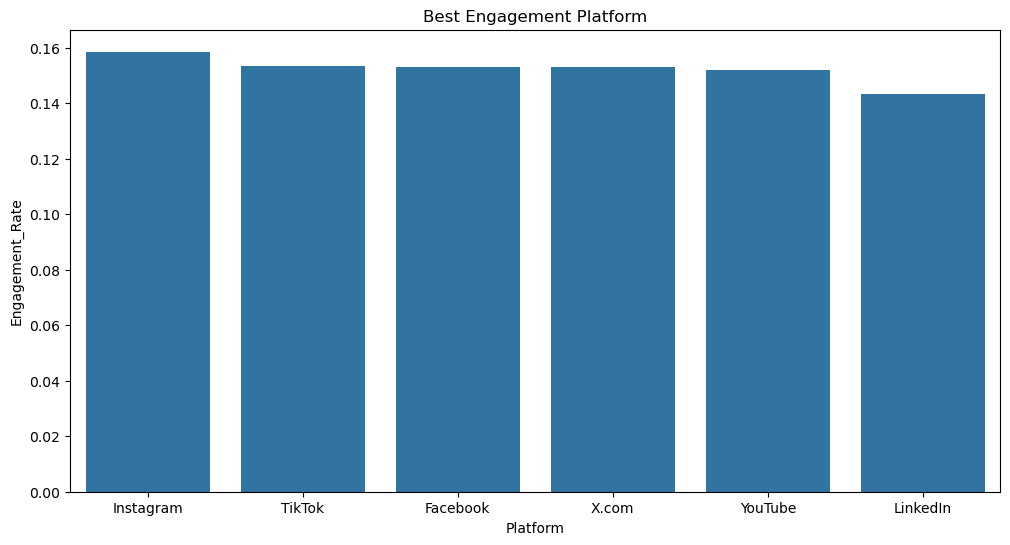

In [152]:
Engagement_Flatform = (
    new_data.groupby('Platform')['Engagement_Rate'].mean().sort_values(ascending=False).reset_index()
)
print(Engagement_Flatform)
plt.figure(figsize=(12,6))
sns.barplot(data=Engagement_Flatform, x='Platform', y='Engagement_Rate')
plt.title('Best Engagement Platform')
plt.show()

### 2. Which categories have the highest engagement?

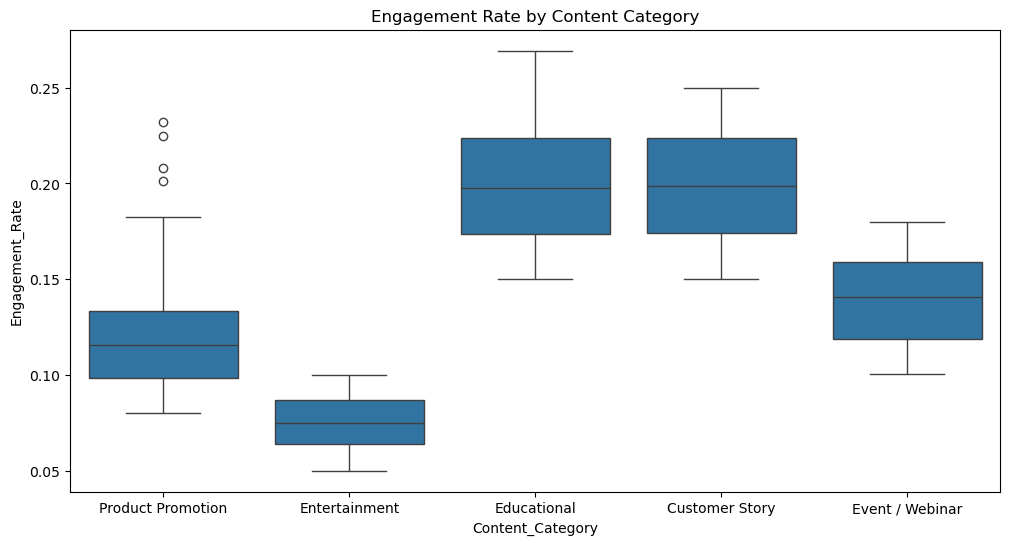

In [77]:
# Which categories have the highest engagement?
plt.figure(figsize=(12,6))
sns.boxplot(data=new_data, x='Content_Category', y='Engagement_Rate')
plt.title('Engagement Rate by Content Category')
plt.show()

### 3. Which content categories have the highest engagement rate on each platform?

    Platform Content_Category  Engagement_Rate
0   Facebook      Educational         0.200426
1  Instagram      Educational         0.200030
2   LinkedIn   Customer Story         0.200515
3     TikTok   Customer Story         0.205328
4      X.com   Customer Story         0.199610
5    YouTube   Customer Story         0.197435


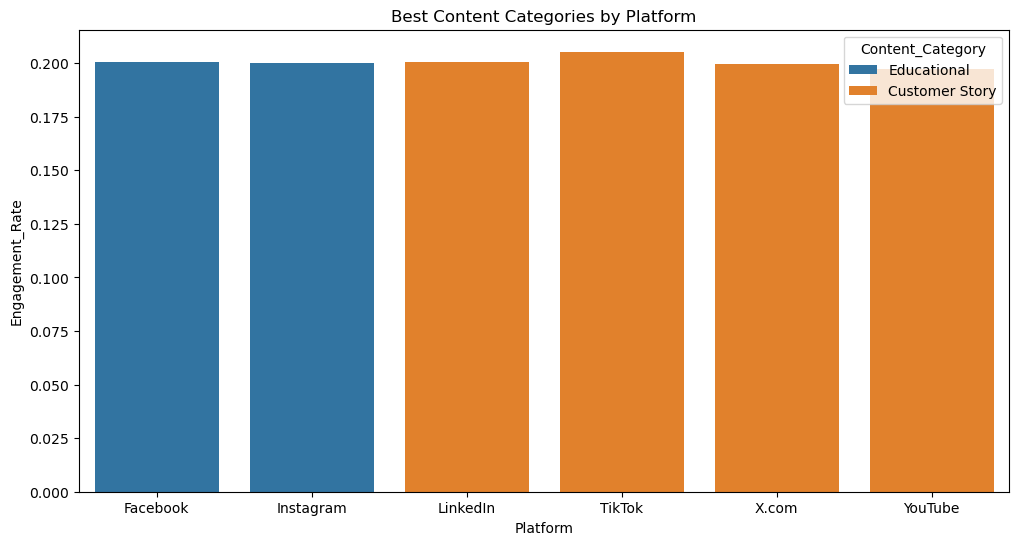

In [78]:
category_type_summary = (new_data.groupby(['Platform','Content_Category'])['Engagement_Rate'].median().reset_index() ) 
idx = category_type_summary.groupby('Platform')['Engagement_Rate'].idxmax() 
best_contetn_type_per_category = category_type_summary.loc[idx].reset_index(drop=True) 
print(best_contetn_type_per_category) 

plt.figure(figsize=(12,6))
sns.barplot(data=best_type_per_category, x='Platform', y='Engagement_Rate', hue='Content_Category')
plt.title('Best Content Categories by Platform')
plt.show()

# INSIGHTS: 

### 4. Which platforms and post types generate the highest engagement rate?

    Platform Post_Type  Engagement_Rate
0   Facebook     Video         0.155729
1  Instagram     Image         0.199551
2   LinkedIn     Image         0.191588
3     TikTok     Video         0.158609
4      X.com      Text         0.169995
5    YouTube     Video         0.158203


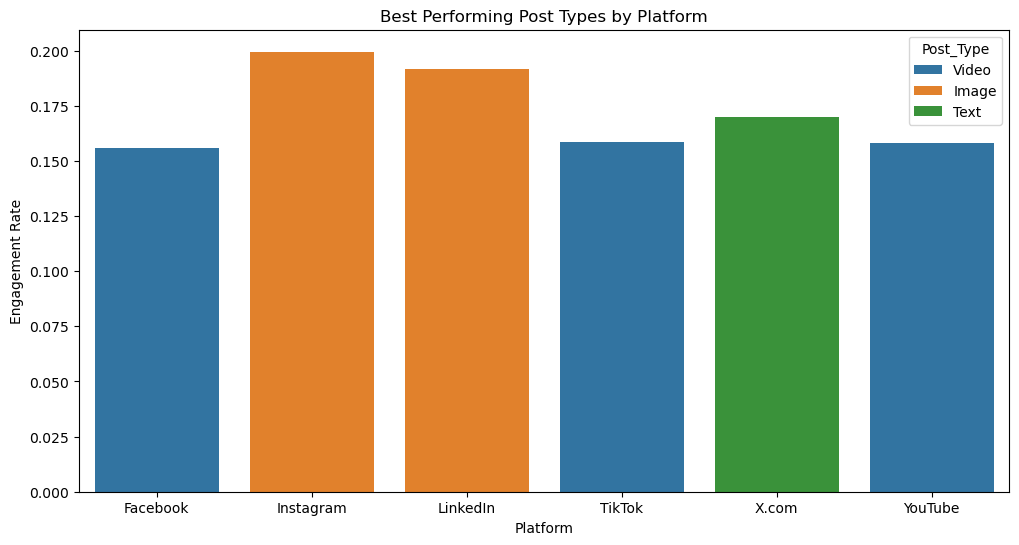

In [79]:
category_type_summary = ( new_data.groupby(['Platform','Post_Type'])['Engagement_Rate'].median().reset_index() ) 
idx = category_type_summary.groupby('Platform')['Engagement_Rate'].idxmax() 
best_post_type_per_category = category_type_summary.loc[idx].reset_index(drop=True) 
print(best_post_type_per_category) 

# Barplot
plt.figure(figsize=(12,6))
sns.barplot(data=best_post_type_per_category, x='Platform', y='Engagement_Rate', hue='Post_Type')
plt.title('Best Performing Post Types by Platform')
plt.xlabel('Platform')
plt.ylabel('Engagement Rate')
plt.show()

### 5. What are the best days and times to post content for maximum engagement?

In [80]:
new_data.columns

Index(['Platform', 'Content_Type', 'Content_Category', 'Post_Type',
       'Engagement_Rate', 'Post_Date', 'Post_Hour', 'Engagement_Level',
       'Day_Name', 'Day_Of_Week'],
      dtype='object')

In [127]:
new_data.head()

,Platform,Content_Type,Content_Category,Post_Type,Engagement_Rate,Post_Date,Post_Hour,Engagement_Level,Day_of_Week,Day_Name,Weekend
0,TikTok,Organic,Product Promotion,Video,0.090951,2024-03-14,15,Low,3,Thursday,False
1,Instagram,Organic,Product Promotion,Video,0.136814,2024-04-24,12,Medium,2,Wednesday,False
2,X.com,Organic,Entertainment,Text,0.056045,2024-12-01,10,Low,6,Sunday,True
3,Instagram,Organic,Entertainment,Carousel,0.066796,2024-07-07,12,Low,6,Sunday,True
4,TikTok,Organic,Educational,Video,0.269302,2024-01-10,11,High,2,Wednesday,False


In [135]:
# Total posts by day-hour
total_posts = (
    new_data.groupby(['Day_of_Week', 'Post_Hour'])
    .size()
    .reset_index(name='total_posts')
)
total_posts

,Day_of_Week,Post_Hour,total_posts
0,0,8,18
1,0,9,27
2,0,10,122
3,0,11,113
4,0,12,106
...,...,...,...
79,6,15,104
80,6,16,106
81,6,17,104
82,6,18,22


In [136]:
# High engagement posts by day-hour
high_posts = (
    new_data[new_data['Engagement_Level'] == 'High']
    .groupby(['Day_of_Week', 'Post_Hour'])
    .size()
    .reset_index(name='high_posts')
)
high_posts 

,Day_of_Week,Post_Hour,high_posts
0,0,8,6
1,0,9,4
2,0,10,21
3,0,11,26
4,0,12,22
...,...,...,...
79,6,15,24
80,6,16,29
81,6,17,27
82,6,18,3


In [137]:
# Merge and calculate success rate
timing_summary = total_posts.merge(
    high_posts,
    on=['Day_of_Week', 'Post_Hour'],
    how='left'
)
timing_summary

,Day_of_Week,Post_Hour,total_posts,high_posts
0,0,8,18,6
1,0,9,27,4
2,0,10,122,21
3,0,11,113,26
4,0,12,106,22
...,...,...,...,...
79,6,15,104,24
80,6,16,106,29
81,6,17,104,27
82,6,18,22,3


In [138]:
timing_summary['high_posts'] = timing_summary['high_posts'].fillna(0)
timing_summary['high_engagement_rate'] = timing_summary['high_posts'] / timing_summary['total_posts']
timing_summary.head(1)

,Day_of_Week,Post_Hour,total_posts,high_posts,high_engagement_rate
0,0,8,18,6,0.333333


Post_Hour     8      9      10     11     12     13     14     15     16  \
Mon        0.333  0.148  0.172  0.230  0.208  0.120  0.176  0.265  0.200   
Tue        0.158  0.132  0.224  0.235  0.228  0.400  0.455  0.293  0.347   
Wed        0.129  0.217  0.190  0.227  0.244  0.217  0.357  0.265  0.241   
Thu        0.333  0.214  0.245  0.279  0.207  0.233  0.286  0.190  0.289   
Fri        0.174  0.242  0.192  0.239  0.209  0.350  0.150  0.167  0.229   
Sat        0.114  0.226  0.253  0.274  0.184  0.160  0.310  0.184  0.217   
Sun        0.227  0.219  0.218  0.204  0.323  0.286  0.167  0.231  0.274   

Post_Hour     17     18     19  
Mon        0.245  0.375  0.160  
Tue        0.192  0.217  0.286  
Wed        0.259  0.161  0.115  
Thu        0.302  0.320  0.263  
Fri        0.294  0.281  0.125  
Sat        0.216  0.303  0.360  
Sun        0.260  0.136  0.200  


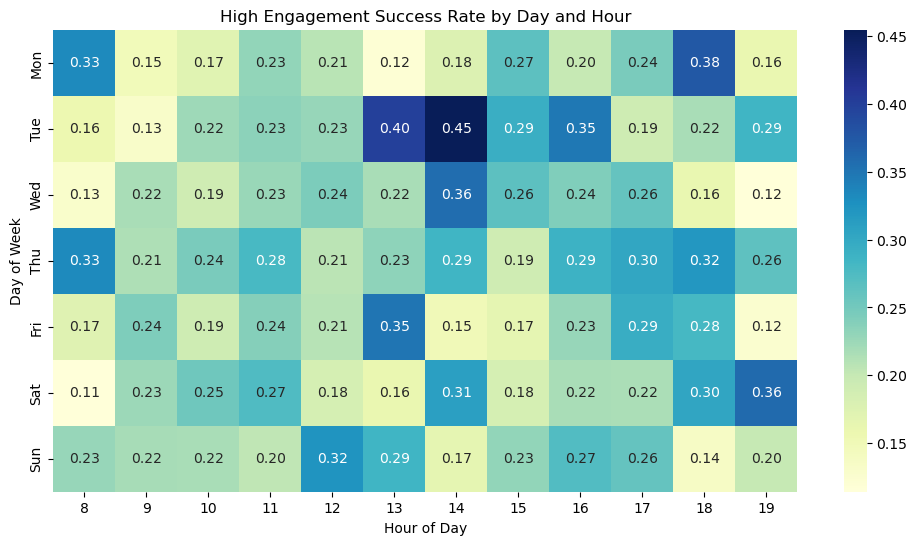

In [108]:
# Pivot for heatmap
timing_heatmap = timing_summary.pivot(
    index='Day_of_Week',
    columns='Post_Hour',
    values='high_engagement_rate'
)

timing_heatmap.index = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

print(timing_heatmap.round(3))

plt.figure(figsize=(12, 6))
sns.heatmap(timing_heatmap, annot=True, fmt='.2f', cmap='YlGnBu')
plt.title('High Engagement Success Rate by Day and Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Day of Week')
plt.show()